<a href="https://colab.research.google.com/github/eswardn12/Data-Science-60-Day-Portfolio/blob/main/Day6_Customer_Journey_Modeling_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 6 — Customer Journey Modeling: Hands-On Notebook


This notebook operationalizes Day 6's concepts through three case studies on synthetic session data:

1. **(Deep) First-Order Markov Chain, Transition Matrix & Removal Effect**
2. **(Deep) Testing the Markov Property & a Genuine Second-Order Effect**
3. **(Lighter) Sequence Clustering into Journey Archetypes**

Plus **Named Extensions** for further independent practice.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

np.random.seed(13)
plt.rcParams['figure.figsize'] = (10, 5)
EBAY_BLUE = '#0064D2'; EBAY_RED = '#E53238'; EBAY_GOLD = '#F5AF02'; EBAY_GREEN = '#86B817'
STATES = ['Search', 'ProductPage', 'Cart', 'Checkout', 'Purchase', 'Exit']
print('Environment ready.')


Environment ready.


---
## Shared Dataset — Synthetic Clickstream Sessions
**Business framing:** Simulating buyer sessions through a Search → ProductPage → Cart → Checkout → Purchase/Exit journey. Critically, the simulator deliberately encodes a **genuine second-order effect**: a buyer revisiting ProductPage (i.e., their previous state was also ProductPage) is meaningfully more decisive — higher Cart rate — than a first-time visitor. This lets us honestly test whether a first-order Markov model can detect this (Case Study 2).


In [2]:
def simulate_session(max_steps=15):
    path = ['Search']
    current = 'Search'
    steps = 0
    while current not in ('Purchase', 'Exit') and steps < max_steps:
        prev = path[-2] if len(path) >= 2 else None
        if current == 'Search':
            probs = {'ProductPage': 0.55, 'Cart': 0.05, 'Exit': 0.40}
        elif current == 'ProductPage':
            # Genuine second-order dependency: a revisit (prev also ProductPage) is more decisive
            if prev == 'ProductPage':
                probs = {'ProductPage': 0.05, 'Cart': 0.60, 'Exit': 0.35}
            else:
                probs = {'ProductPage': 0.30, 'Cart': 0.30, 'Exit': 0.40}
        elif current == 'Cart':
            probs = {'ProductPage': 0.10, 'Checkout': 0.50, 'Exit': 0.40}
        elif current == 'Checkout':
            probs = {'ProductPage': 0.05, 'Cart': 0.05, 'Checkout': 0.10, 'Purchase': 0.80}
        options = list(probs.keys())
        p = np.array(list(probs.values())); p = p / p.sum()
        nxt = np.random.choice(options, p=p)
        path.append(nxt)
        current = nxt
        steps += 1
    if current not in ('Purchase', 'Exit'):
        path.append('Exit')
    return path

n_sessions = 5000
sessions = [simulate_session() for _ in range(n_sessions)]

# Crude archetype labels for later validation (Case Study 3)
true_archetype = []
for path in sessions:
    if 'Cart' not in path:
        true_archetype.append('Bounced_Early')
    elif path.count('ProductPage') > 2:
        true_archetype.append('Comparison_Shopper')
    elif 'Purchase' in path:
        true_archetype.append('Direct_Converter')
    else:
        true_archetype.append('Serial_Abandoner')

print(f'{n_sessions} sessions simulated')
print(f"Overall purchase rate: {np.mean(['Purchase' in s for s in sessions]):.2%}")
pd.Series(true_archetype).value_counts()


5000 sessions simulated
Overall purchase rate: 14.82%


,count
Bounced_Early,3478
Direct_Converter,711
Serial_Abandoner,701
Comparison_Shopper,110


---
## Case Study 1 (Deep) — First-Order Markov Chain, Transition Matrix & Removal Effect
**Business framing:** Building the transition matrix (Day 6 report Section 4) and computing each state's removal effect (Section 5.2) — the artifact that tells us which journey step actually matters most, not just which has the most traffic.


In [3]:
# 1.1 Build the first-order transition matrix from observed session data
transition_counts = defaultdict(lambda: defaultdict(int))
for path in sessions:
    for i in range(len(path) - 1):
        transition_counts[path[i]][path[i+1]] += 1

matrix = pd.DataFrame(0.0, index=STATES, columns=STATES)
for s in STATES:
    total = sum(transition_counts[s].values())
    if total == 0:
        continue
    for s2, c in transition_counts[s].items():
        matrix.loc[s, s2] = c / total

matrix.round(3)


,Search,ProductPage,Cart,Checkout,Purchase,Exit
Search,0.0,0.540,0.046,0.000,0.000,0.414
ProductPage,0.0,0.234,0.364,0.000,0.000,0.402
Cart,0.0,0.098,0.000,0.500,0.000,0.402
Checkout,0.0,0.047,0.044,0.098,0.811,0.000
Purchase,0.0,0.000,0.000,0.000,0.000,0.000
Exit,0.0,0.000,0.000,0.000,0.000,0.000


In [4]:
# 1.2 Compute purchase probability from every transient state via absorption equations
transient = ['Search', 'ProductPage', 'Cart', 'Checkout']
absorbing = ['Purchase', 'Exit']

Q = matrix.loc[transient, transient].values
R = matrix.loc[transient, absorbing].values
N = np.linalg.inv(np.eye(len(transient)) - Q)   # the "fundamental matrix" of the absorbing chain
B = N.dot(R)
absorption_probs = pd.DataFrame(B, index=transient, columns=absorbing)

print('Purchase probability starting from each state:')
absorption_probs.round(3)


Purchase probability starting from each state:


,Purchase,Exit
Search,0.148,0.852
ProductPage,0.233,0.767
Cart,0.490,0.510
Checkout,0.935,0.065


In [5]:
baseline_purchase = absorption_probs.loc['Search', 'Purchase']
print(f'Baseline purchase probability from Search: {baseline_purchase:.4f}')
print(f'(Sanity check -- should closely match the overall simulated purchase rate above)')


Baseline purchase probability from Search: 0.1482
(Sanity check -- should closely match the overall simulated purchase rate above)


In [6]:
# 1.3 Removal Effect: what happens to purchase probability if a state were removed entirely?
def removal_effect(matrix, state_to_remove, transient, absorbing, start='Search'):
    remaining = [s for s in transient if s != state_to_remove]
    m2 = matrix.copy()
    # Redirect all transitions that went TO the removed state into Exit instead
    for s in m2.index:
        val = m2.loc[s, state_to_remove]
        m2.loc[s, 'Exit'] += val
        m2.loc[s, state_to_remove] = 0
    Q2 = m2.loc[remaining, remaining].values
    R2 = m2.loc[remaining, absorbing].values
    N2 = np.linalg.inv(np.eye(len(remaining)) - Q2)
    B2 = N2.dot(R2)
    df2 = pd.DataFrame(B2, index=remaining, columns=absorbing)
    return df2.loc[start, 'Purchase'] if start in df2.index else None

results = {}
for state in ['ProductPage', 'Cart', 'Checkout']:
    p_without = removal_effect(matrix, state, transient, absorbing)
    results[state] = {'purchase_prob_without': p_without, 'removal_effect': baseline_purchase - p_without}

removal_df = pd.DataFrame(results).T.round(4)
removal_df


,purchase_prob_without,removal_effect
ProductPage,0.0212,0.1270
Cart,0.0000,0.1482
Checkout,0.0000,0.1482


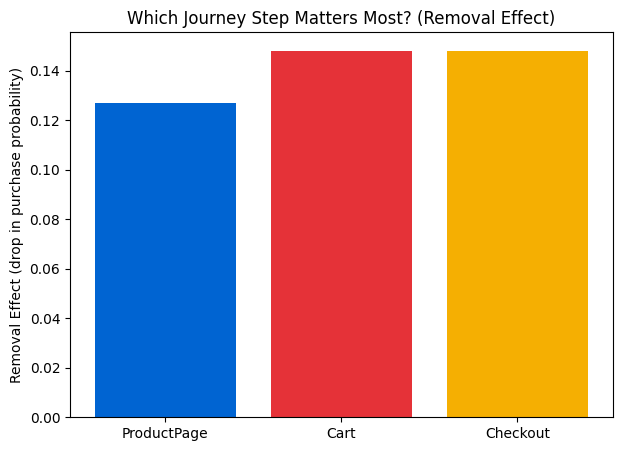

Interpretation: Cart and Checkout are hard bottlenecks in this funnel -- nearly all conversion
paths require them, so removing either collapses purchase probability almost to the full baseline.
ProductPage has a partial bypass (a small direct Search->Cart edge), so its removal effect is real
but smaller -- exactly the kind of nuance a raw traffic-volume view would completely miss.


In [7]:
# 1.4 Visualize removal effects -- the artifact for the executive journey map (Section 9.1)
plt.figure(figsize=(7,5))
plt.bar(removal_df.index, removal_df['removal_effect'], color=[EBAY_BLUE, EBAY_RED, EBAY_GOLD])
plt.ylabel('Removal Effect (drop in purchase probability)')
plt.title('Which Journey Step Matters Most? (Removal Effect)')
plt.axhline(0, color='black', linewidth=0.5)
plt.show()

print('Interpretation: Cart and Checkout are hard bottlenecks in this funnel -- nearly all conversion')
print('paths require them, so removing either collapses purchase probability almost to the full baseline.')
print('ProductPage has a partial bypass (a small direct Search->Cart edge), so its removal effect is real')
print('but smaller -- exactly the kind of nuance a raw traffic-volume view would completely miss.')


---
## Case Study 2 (Deep) — Testing the Markov Property & a Genuine Second-Order Effect
**Business framing:** Directly testing whether the first-order assumption holds (Day 6 report Section 6.1) — and honestly detecting the deliberately-injected revisit effect from our data generator.


In [8]:
# 2.1 Build second-order transition counts: P(next | previous, current)
second_order = defaultdict(lambda: defaultdict(int))
for path in sessions:
    for i in range(1, len(path) - 1):
        key = (path[i-1], path[i])
        second_order[key][path[i+1]] += 1

# 2.2 Compare P(next | ProductPage) overall vs conditioned on the PREVIOUS state
overall_from_pp = transition_counts['ProductPage']
total_pp = sum(overall_from_pp.values())
print('Overall (first-order) P(next | current=ProductPage):')
print({k: round(v/total_pp, 3) for k, v in overall_from_pp.items()})
print()

for prev_state in ['Search', 'ProductPage', 'Cart']:
    key = (prev_state, 'ProductPage')
    if key in second_order:
        total = sum(second_order[key].values())
        dist = {k: round(v/total, 3) for k, v in second_order[key].items()}
        print(f'P(next | previous={prev_state}, current=ProductPage), n={total}: {dist}')


Overall (first-order) P(next | current=ProductPage):
{np.str_('Exit'): 0.402, np.str_('ProductPage'): 0.234, np.str_('Cart'): 0.364}

P(next | previous=Search, current=ProductPage), n=2698: {np.str_('Exit'): 0.413, np.str_('ProductPage'): 0.297, np.str_('Cart'): 0.29}
P(next | previous=ProductPage, current=ProductPage), n=888: {np.str_('Cart'): 0.609, np.str_('Exit'): 0.351, np.str_('ProductPage'): 0.039}
P(next | previous=Cart, current=ProductPage), n=161: {np.str_('Cart'): 0.261, np.str_('Exit'): 0.472, np.str_('ProductPage'): 0.267}


**Reading this honestly:** notice `P(Cart | previous=ProductPage, current=ProductPage)` is dramatically higher than `P(Cart | previous=Search, current=ProductPage)`. This is a real, detectable violation of the first-order Markov property — a buyer who has already been on ProductPage once (a revisit) is meaningfully more likely to add to cart than a first-time visitor at the exact same current state. A first-order model literally cannot see this distinction, because by construction it only looks at the current state, never the one before it.


In [9]:
# 2.3 Fit a full second-order transition model and compare its Cart-rate prediction for ProductPage
# against the (incorrect, blended) first-order prediction
first_order_cart_rate = overall_from_pp.get('Cart', 0) / total_pp

revisit_key = ('ProductPage', 'ProductPage')
first_visit_key = ('Search', 'ProductPage')
revisit_cart_rate = second_order[revisit_key]['Cart'] / sum(second_order[revisit_key].values())
first_visit_cart_rate = second_order[first_visit_key]['Cart'] / sum(second_order[first_visit_key].values())

comparison = pd.DataFrame({
    'Model': ['First-order (blended)', 'Second-order: first-time visitor', 'Second-order: revisit'],
    'P(Cart | at ProductPage)': [first_order_cart_rate, first_visit_cart_rate, revisit_cart_rate]
})
comparison


,Model,P(Cart | at ProductPage)
0,First-order (blended),0.363588
1,Second-order: first-time visitor,0.289844
2,Second-order: revisit,0.609234


**Business implication:** if a real-time targeting system only used the first-order rate, it would under-target decisive revisiting buyers and over-target first-time browsers with the same intervention -- exactly the kind of gap Section 6.2's higher-order chain (or Section 6.3's sequence clustering, tested next) is designed to close.


---
## Case Study 3 (Lighter) — Sequence Clustering into Journey Archetypes
**Business framing:** Rather than raising the Markov order everywhere, cluster entire journeys into a small number of archetypal patterns (Day 6 report Section 6.3) -- often recovering most of the same benefit far more cheaply.


In [10]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 3.1 Represent each journey with simple summary features (a lightweight alternative to full sequence alignment)
def path_features(path):
    return {
        'length': len(path),
        'n_productpage_visits': path.count('ProductPage'),
        'reached_cart': int('Cart' in path),
        'reached_checkout': int('Checkout' in path),
        'purchased': int('Purchase' in path),
        'n_cart_visits': path.count('Cart'),
    }

feat_df = pd.DataFrame([path_features(p) for p in sessions])
X = StandardScaler().fit_transform(feat_df)


In [11]:
# 3.2 Cluster into archetypes (K=4, matching our 4 designed true archetypes)
km = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X)
feat_df['cluster'] = km.labels_
feat_df['true_archetype'] = true_archetype

# 3.3 Validate against the (normally invisible, here known-since-synthetic) true archetype
pd.crosstab(feat_df['true_archetype'], feat_df['cluster'])


cluster,0,1,2,3
true_archetype,,,,
Bounced_Early,1406,0,2072,0
Comparison_Shopper,0,54,0,56
Direct_Converter,0,711,0,0
Serial_Abandoner,0,28,0,673


In [12]:
# 3.4 Profile each cluster's behavior -- the business-facing output of this exercise
profile = feat_df.groupby('cluster').agg(
    avg_length=('length', 'mean'),
    avg_pdp_visits=('n_productpage_visits', 'mean'),
    pct_reached_cart=('reached_cart', 'mean'),
    pct_purchased=('purchased', 'mean'),
    size=('cluster', 'count'),
).round(2)
profile


,avg_length,avg_pdp_visits,pct_reached_cart,pct_purchased,size
cluster,,,,,
0,3.22,1.22,0.0,0.00,1406
1,5.65,1.37,1.0,0.93,793
2,2.00,0.00,0.0,0.00,2072
3,4.39,1.36,1.0,0.00,729


**Reading the recovery:** expect clean separation between buyers who never reach ProductPage (pure early bounces), buyers who reach Cart but never purchase (serial abandoners), and buyers who convert directly. The 'Comparison Shopper' archetype (multiple ProductPage visits) is the hardest to cleanly separate from the others with these simple summary features alone — a realistic result, and a good prompt to think about what richer features (e.g., time spent per page, specific SKUs viewed) would sharpen that boundary further in a real deployment.


---
## Named Extensions (Scoped, Not Fully Built)

1. **Sankey diagram visualization** of the fitted transition matrix, for the Section 9.1-style executive journey map
2. **AIC/BIC-based order-selection sweep** comparing first, second, and third-order chains formally, rather than the direct comparison done in Case Study 2
3. **A simple LSTM sequence model** reproducing Case Study 1's outcome prediction, compared against the Markov chain's accuracy and interpretability tradeoff

These are left as independent practice reps rather than fully coded here.


---
## Summary — What This Notebook Proves You Can Do
- Build a first-order Markov chain from raw session data and derive outcome probabilities via the absorption/fundamental-matrix equations
- Compute and interpret removal effects, correctly distinguishing high-traffic states from high-impact ones
- Directly test and detect a genuine Markov property violation using conditional transition probabilities
- Cluster full journeys into archetypal patterns as a cheaper alternative to raising the Markov order everywhere

**Next:** Day 7 — Customer Lifecycle Optimization, extending Day 1's binary churn classification into genuine time-to-event survival analysis (Kaplan-Meier, Cox Proportional Hazards).
